In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import pandas as pd
import pyarrow.parquet as pq

path = "../datasets/NF-UNSW-NB15-v2.parquet"

# cek label (tetap cepat)
df = pd.read_parquet(path, columns=["Label"])
print(df["Label"].value_counts(normalize=True))

frac = 0.001

parquet_file = pq.ParquetFile(path)

samples = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()

    sampled_chunk = (
        chunk
        .groupby("Label", group_keys=False)
        .sample(frac=frac, random_state=42)
    )

    samples.append(sampled_chunk)

df_sample = pd.concat(samples, ignore_index=True)

print("Sample shape:", df_sample.shape)
print(df_sample["Label"].value_counts(normalize=True))

df_sample.to_parquet("../datasets/NF-UNSW-NB15-v2_sample.parquet", index=False)

Label
0    0.960233
1    0.039767
Name: proportion, dtype: float64
Sample shape: (2390, 45)
Label
0    0.960251
1    0.039749
Name: proportion, dtype: float64


In [3]:
df_sample.head()

,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack
0,59.166.0.2,38736,149.171.126.8,43673,17,0.0,512,4,304,4,...,0,0,0,0,0,0,0,0.0,0,Benign
1,59.166.0.0,33303,149.171.126.9,5190,6,0.0,1470,22,1728,14,...,10136,11584,28416,111,0,0,0,0.0,0,Benign
2,59.166.0.2,14453,149.171.126.6,21,6,1.0,2059,37,2812,39,...,21720,18824,63744,249,0,0,0,125.0,0,Benign
3,59.166.0.6,34050,149.171.126.8,53706,6,0.0,8928,14,424,8,...,5792,10136,39936,156,0,0,0,0.0,0,Benign
4,59.166.0.9,3506,149.171.126.5,1523,6,0.0,2334,36,16438,38,...,21720,14480,6912,27,0,0,0,0.0,0,Benign


In [4]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2390 entries, 0 to 2389
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IPV4_SRC_ADDR                2390 non-null   object 
 1   L4_SRC_PORT                  2390 non-null   int64  
 2   IPV4_DST_ADDR                2390 non-null   object 
 3   L4_DST_PORT                  2390 non-null   int64  
 4   PROTOCOL                     2390 non-null   int64  
 5   L7_PROTO                     2390 non-null   float64
 6   IN_BYTES                     2390 non-null   int64  
 7   IN_PKTS                      2390 non-null   int64  
 8   OUT_BYTES                    2390 non-null   int64  
 9   OUT_PKTS                     2390 non-null   int64  
 10  TCP_FLAGS                    2390 non-null   int64  
 11  CLIENT_TCP_FLAGS             2390 non-null   int64  
 12  SERVER_TCP_FLAGS             2390 non-null   int64  
 13  FLOW_DURATION_MILL

In [5]:
df_sample.describe().T

,count,mean,std,min,25%,50%,75%,max
L4_SRC_PORT,2390.0,3.245231e+04,1.927319e+04,0.0,15803.25,32482.5,4.868325e+04,6.553100e+04
L4_DST_PORT,2390.0,1.138896e+04,1.847786e+04,0.0,53.00,111.0,1.621500e+04,6.543000e+04
PROTOCOL,2390.0,9.213389e+00,1.084834e+01,1.0,6.00,6.0,6.000000e+00,2.220000e+02
L7_PROTO,2390.0,3.099163e+00,1.365360e+01,0.0,0.00,0.0,1.000000e+00,1.390000e+02
IN_BYTES,2390.0,4.214087e+03,1.816228e+04,9.0,481.00,1684.0,3.311000e+03,6.389340e+05
IN_PKTS,2390.0,3.715941e+01,6.517069e+01,1.0,4.00,18.0,4.400000e+01,6.620000e+02
OUT_BYTES,2390.0,3.904132e+04,1.618485e+05,0.0,312.00,2478.0,1.540200e+04,1.641360e+06
OUT_PKTS,2390.0,4.841799e+01,1.210454e+02,0.0,4.00,18.0,4.500000e+01,1.278000e+03
TCP_FLAGS,2390.0,1.984017e+01,1.118734e+01,0.0,19.00,27.0,2.700000e+01,2.700000e+01
CLIENT_TCP_FLAGS,2390.0,1.956234e+01,1.110508e+01,0.0,19.00,27.0,2.700000e+01,2.700000e+01


In [6]:
df_sample["Label"].value_counts()

Label
0    2295
1      95
Name: count, dtype: int64

In [7]:
df_sample["Attack"].value_counts()

Attack
Benign            2295
Exploits            27
Fuzzers             22
Generic             19
DoS                 12
Reconnaissance      10
Analysis             3
Backdoor             2
Name: count, dtype: int64

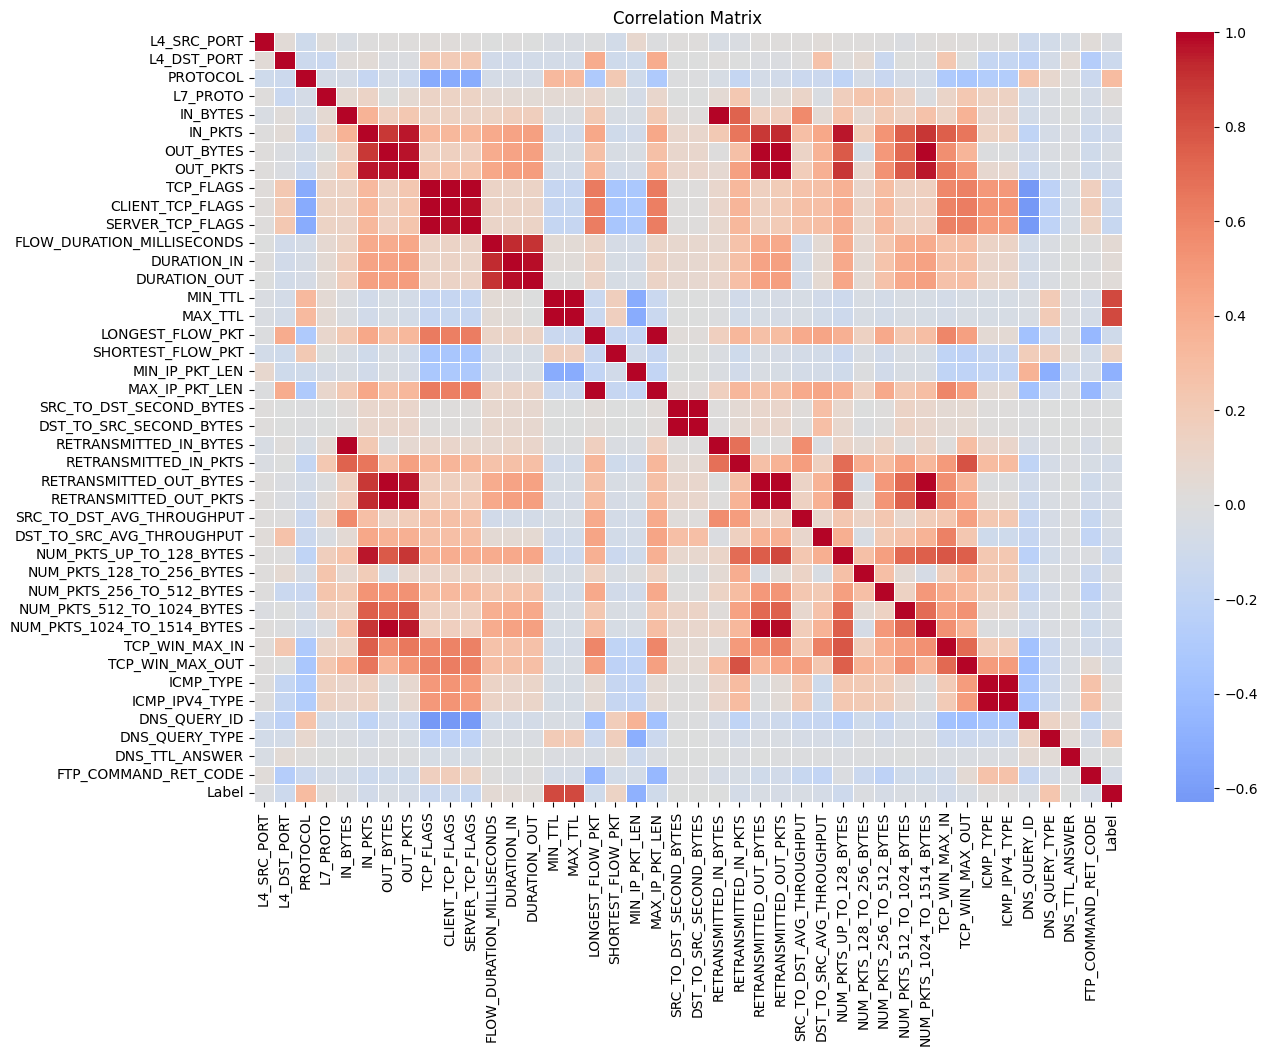

In [8]:
plt.figure(figsize=(14,10))
corr = df_sample.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

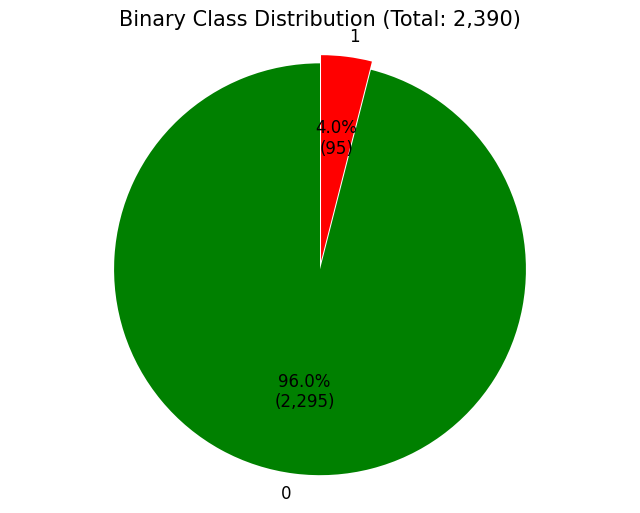

In [9]:
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,})'
    return inner

# ambil data label
label_counts = df_sample["Label"].value_counts()

labels = label_counts.index.astype(str)
sizes = label_counts.values
colors = ["green", "red"]

plt.figure(figsize=(8, 6))

plt.pie(
    sizes,
    labels=labels,
    autopct=autopct_format(sizes),
    colors=colors,
    startangle=90,
    explode=[0.02] * len(labels),
    textprops={'fontsize': 12}
)

plt.title(f'Binary Class Distribution (Total: {label_counts.sum():,})', fontsize=15)

plt.axis('equal')
plt.show()

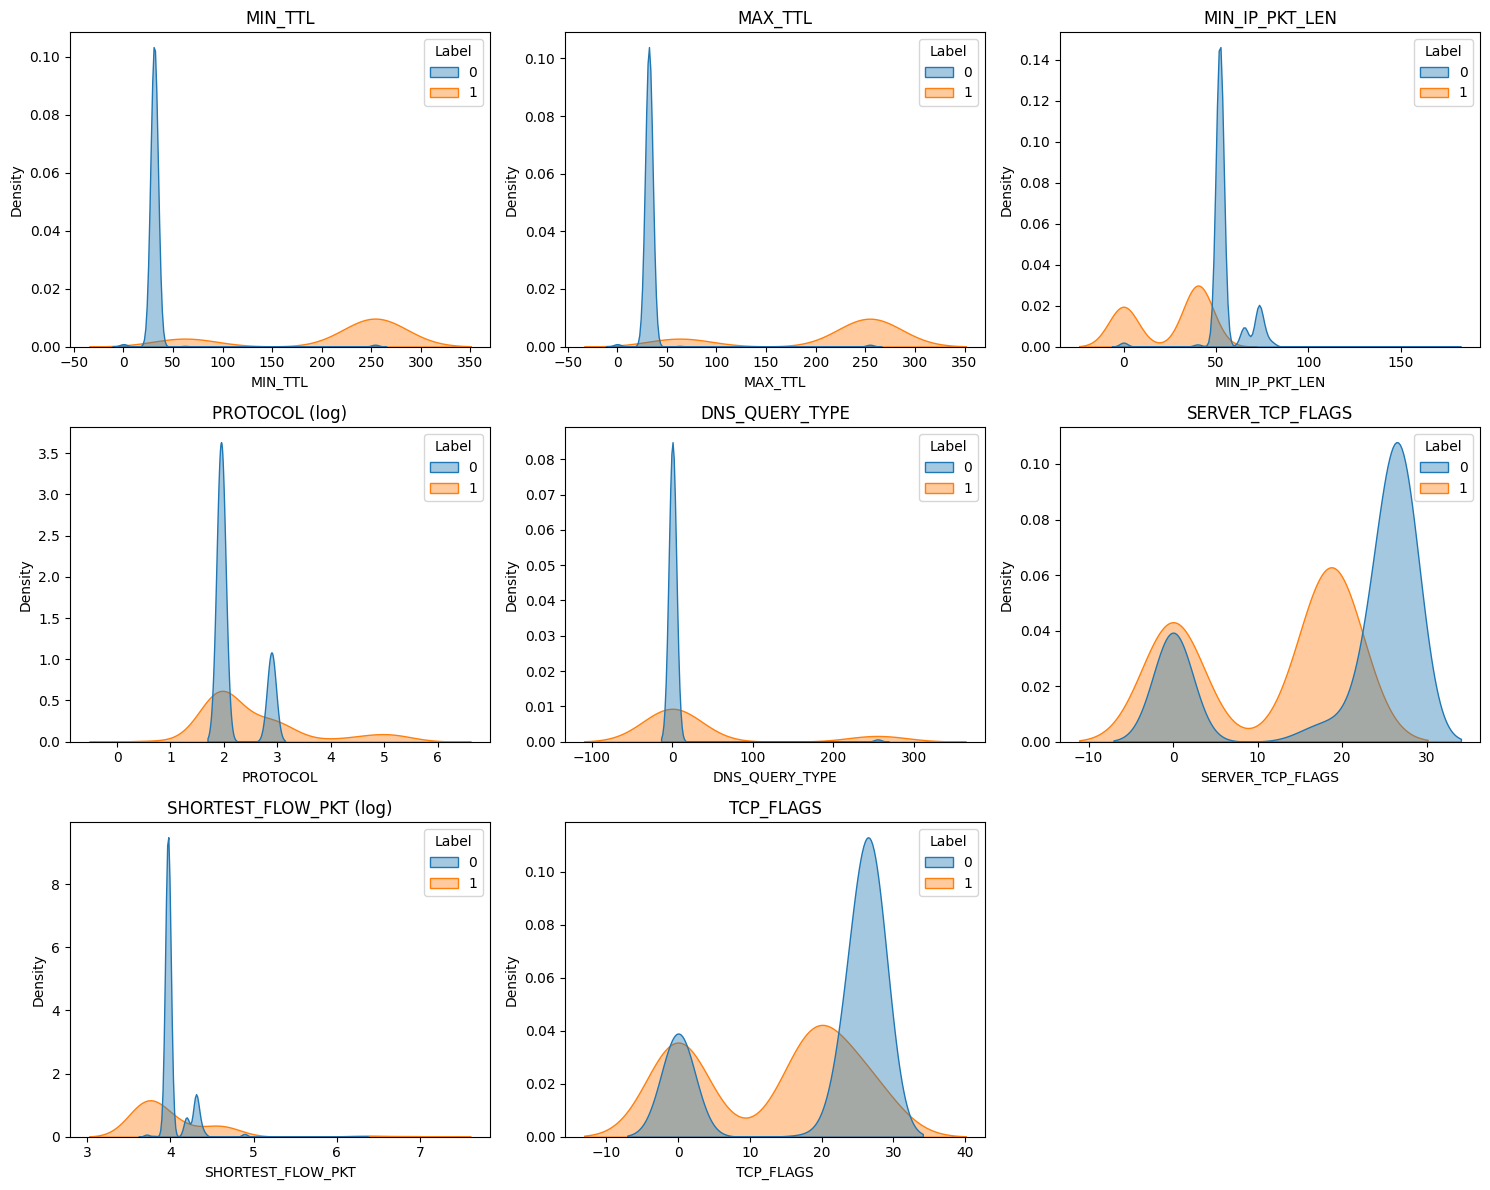

In [10]:
numeric_df = df_sample.select_dtypes(include=["int64", "float64"])

corr_with_label = (
    numeric_df
    .corr()["Label"]
    .abs()
    .sort_values(ascending=False)
)

top_features = corr_with_label.index[1:9]
n_cols = 3
n_rows = int(np.ceil(len(top_features) / n_cols))
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(top_features):
    plt.subplot(n_rows, n_cols, i + 1)

    values = df_sample[col]

    if (values > 0).all():
        values = np.log1p(values)
        title = f"{col} (log)"
    else:
        title = col

    sns.kdeplot(
        x=values,
        hue=df_sample["Label"],
        common_norm=False,
        fill=True,
        alpha=0.4
    )

    plt.title(title)

plt.tight_layout()
plt.show()

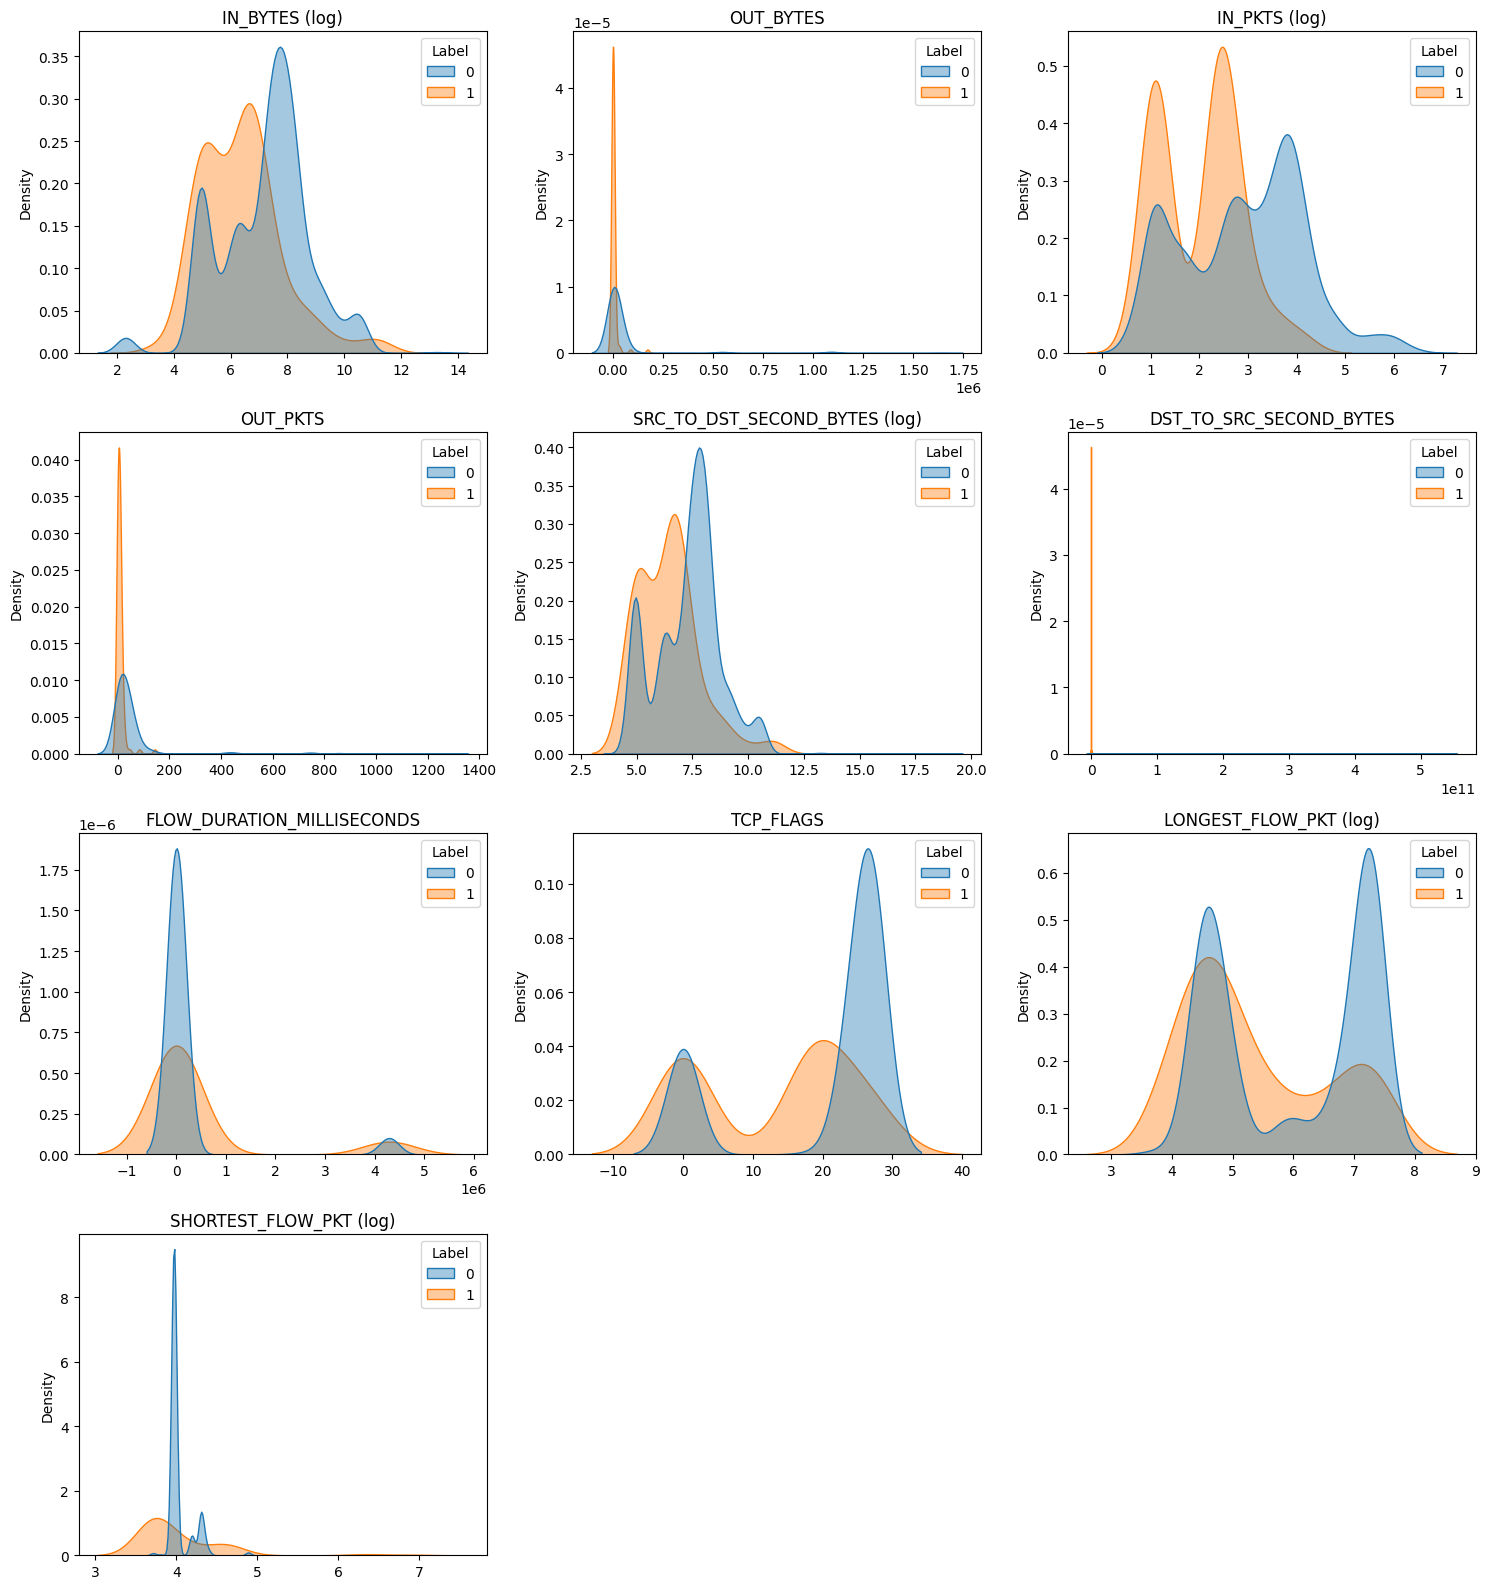

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Top 10 Features You Selected
# ==============================

top_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "FLOW_DURATION_MILLISECONDS",
    "TCP_FLAGS",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT"
]

# Keep only numeric columns
numeric_df = df_sample.select_dtypes(include=["int64", "float64"])

# Clean data
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)
numeric_df.fillna(0, inplace=True)

# ==============================
# Plot Layout
# ==============================

n_cols = 3
n_rows = int(np.ceil(len(top_features) / n_cols))

plt.figure(figsize=(15, 4 * n_rows))

# ==============================
# Plot Loop
# ==============================

for i, col in enumerate(top_features):

    if col not in numeric_df.columns:
        continue

    plt.subplot(n_rows, n_cols, i + 1)

    values = numeric_df[col]

    # Log transform for skewed positive features
    if (values > 0).all():
        values = np.log1p(values)
        title = f"{col} (log)"
    else:
        title = col

    sns.kdeplot(
        x=values,
        hue=df_sample["Label"],
        common_norm=False,
        fill=True,
        alpha=0.4
    )

    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


In [12]:
from sklearn.feature_selection import f_classif

X = numeric_df[top_features]
y = df_sample["Label"]

f_scores, p_values = f_classif(X, y)

anova_df = pd.DataFrame({
    "Feature": top_features,
    "F_score": f_scores,
    "p_value": p_values
})

anova_df = anova_df.sort_values(
    by="F_score",
    ascending=False
)

print(anova_df)


                      Feature    F_score       p_value
9           SHORTEST_FLOW_PKT  42.624095  8.075963e-11
7                   TCP_FLAGS  36.965708  1.395687e-09
8            LONGEST_FLOW_PKT  24.193499  9.305428e-07
2                     IN_PKTS  17.706901  2.672120e-05
3                    OUT_PKTS  10.720512  1.074672e-03
6  FLOW_DURATION_MILLISECONDS   5.349940  2.080757e-02
1                   OUT_BYTES   4.616680  3.176273e-02
0                    IN_BYTES   0.675477  4.112305e-01
4     SRC_TO_DST_SECOND_BYTES   0.043727  8.343802e-01
5     DST_TO_SRC_SECOND_BYTES   0.041390  8.388039e-01


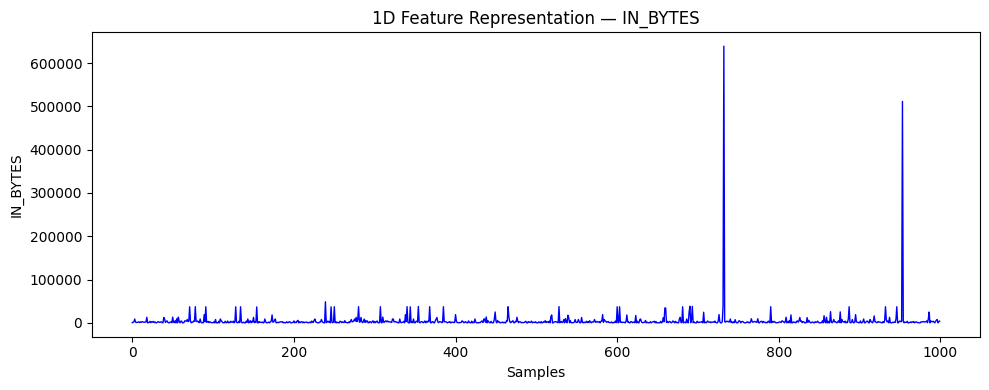

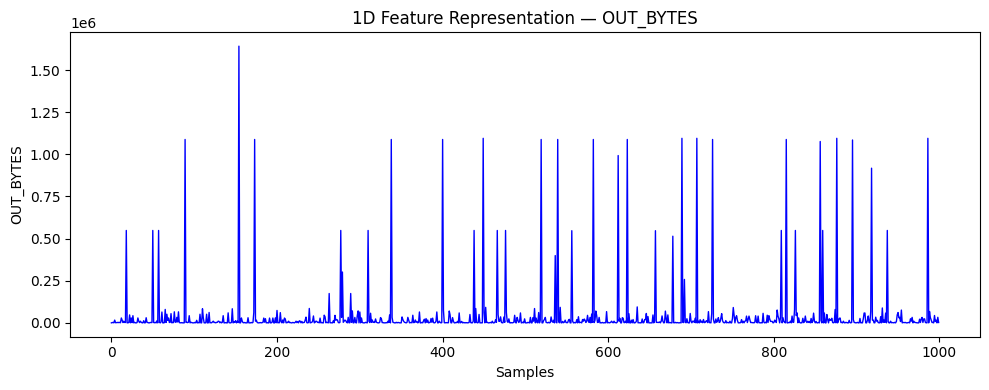

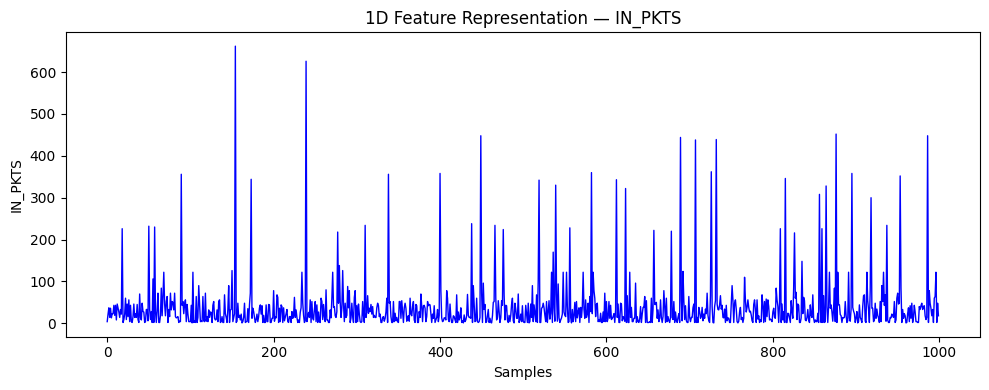

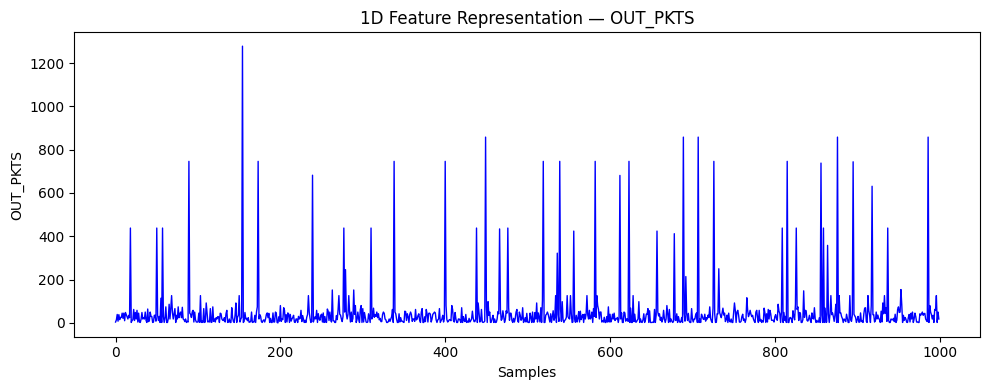

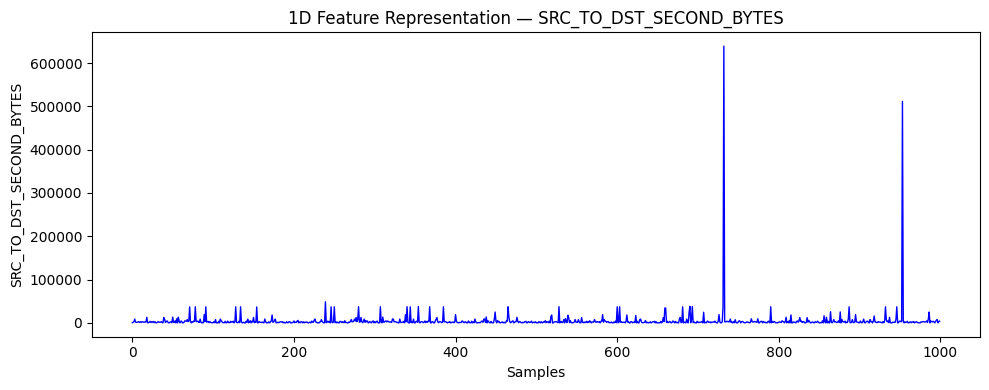

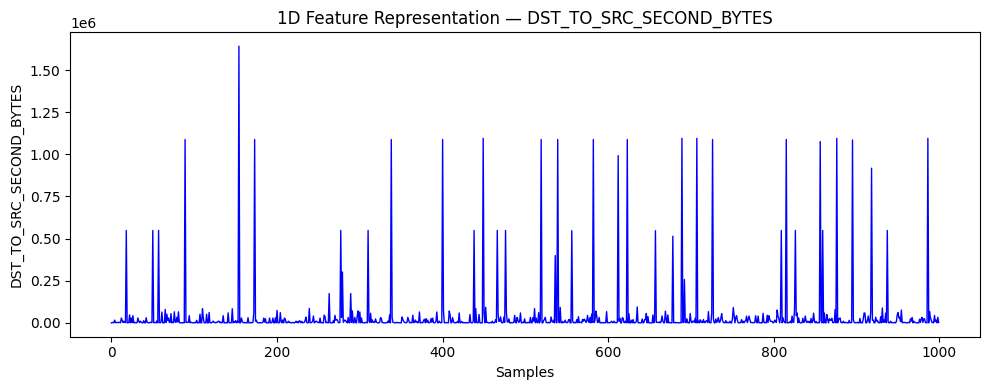

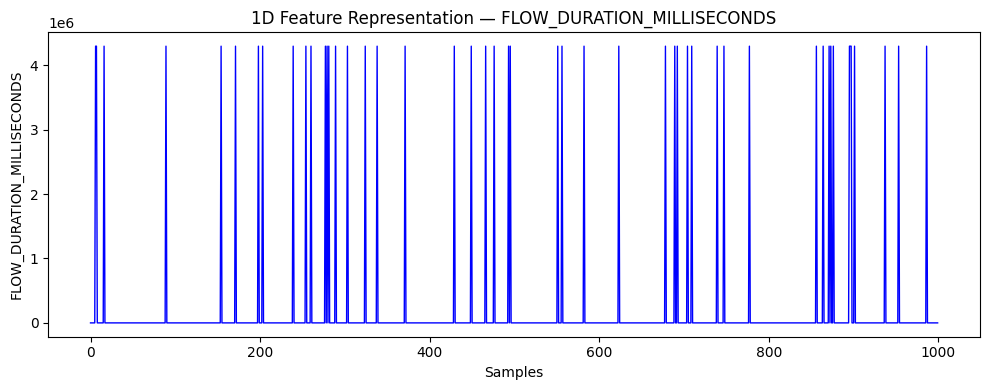

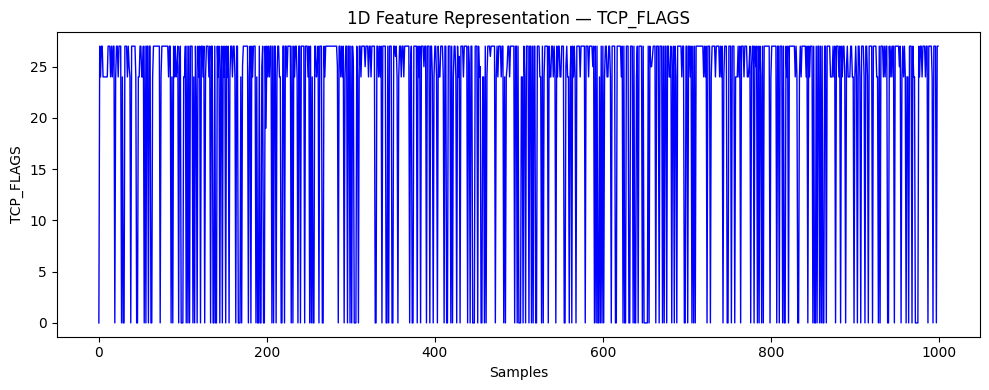

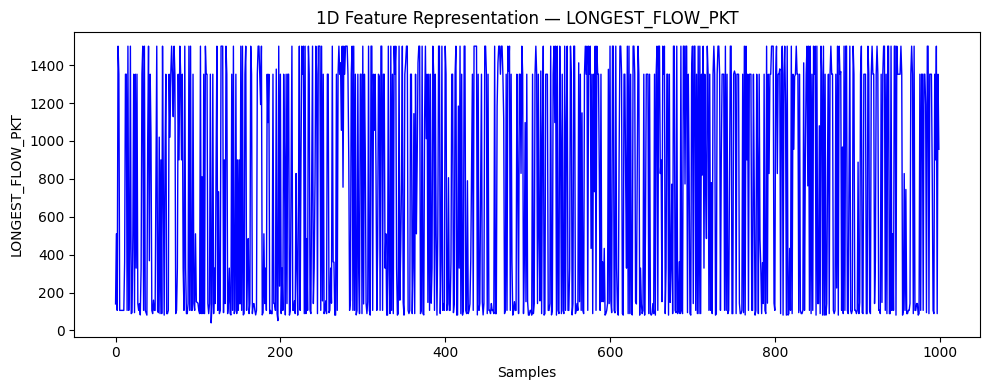

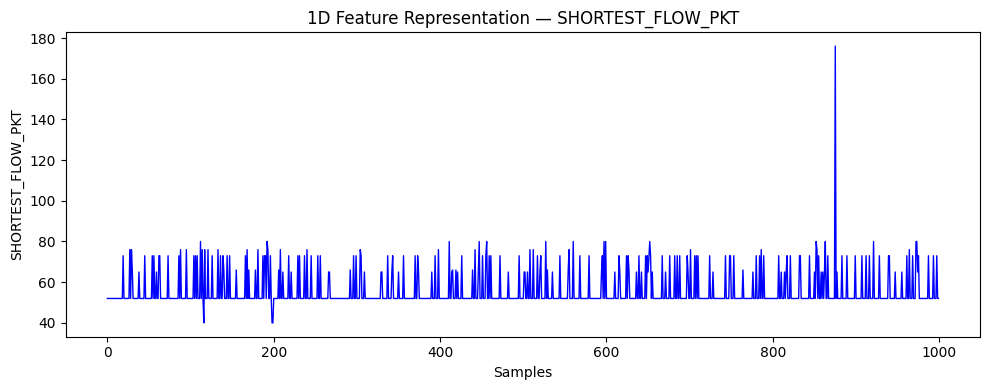

In [13]:
import matplotlib.pyplot as plt

for col in top_features:

    if col not in numeric_df.columns:
        continue

    plt.figure(figsize=(10,4))

    values = numeric_df[col].values[:1000]  # first 1000 samples

    plt.plot(values, color="blue", linewidth=1)

    plt.title(f"1D Feature Representation — {col}")
    plt.xlabel("Samples")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

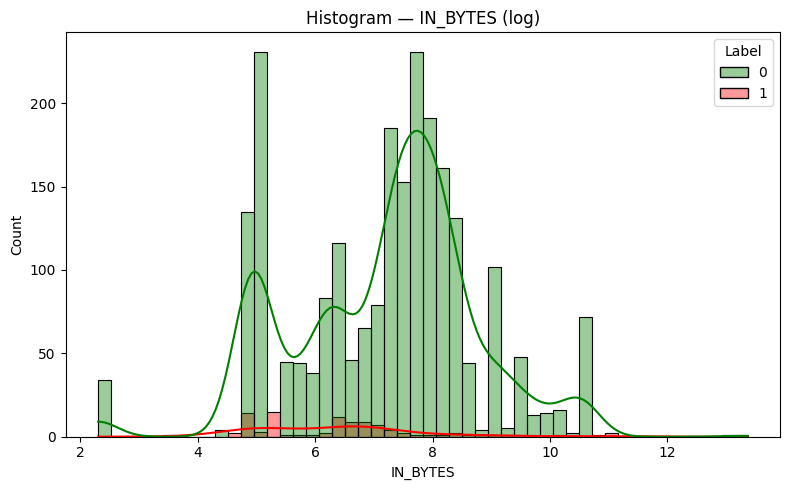

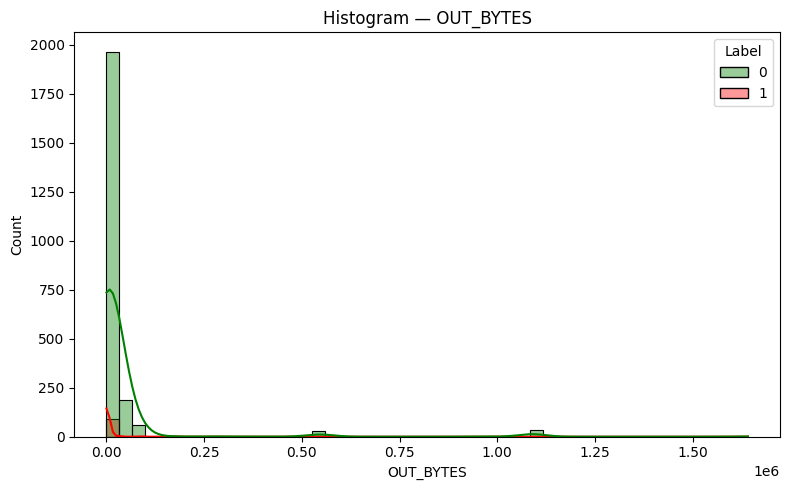

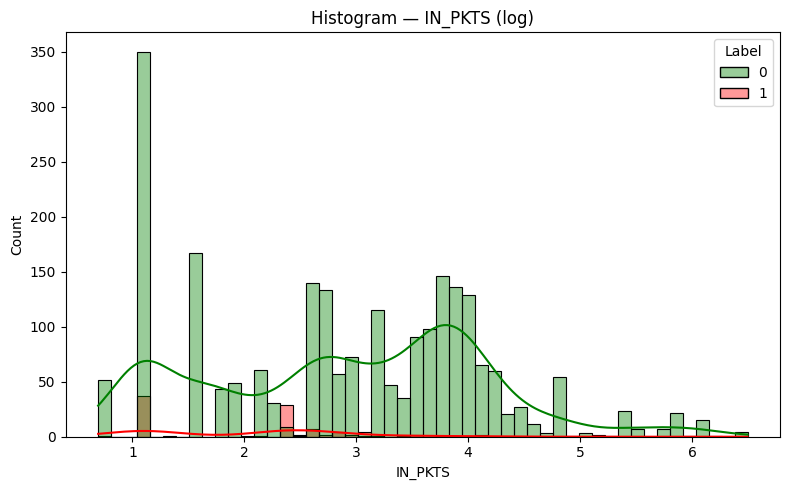

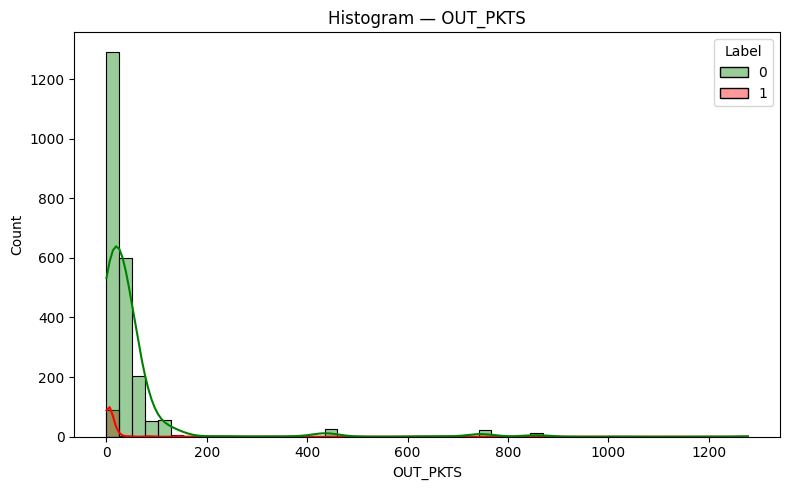

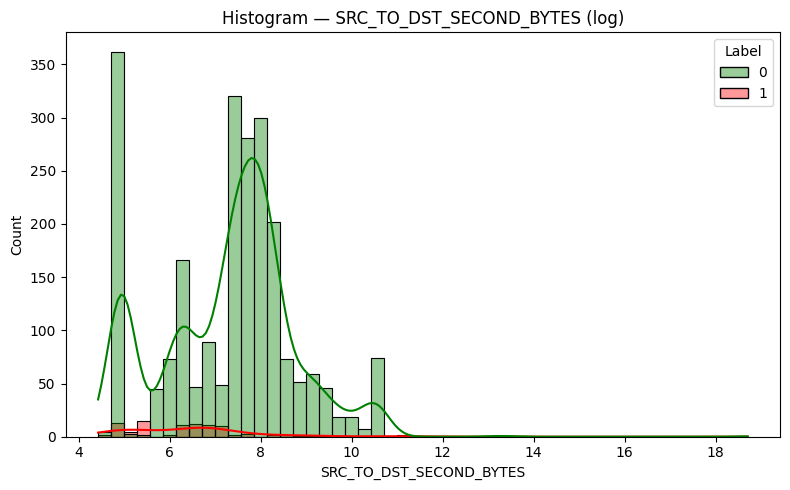

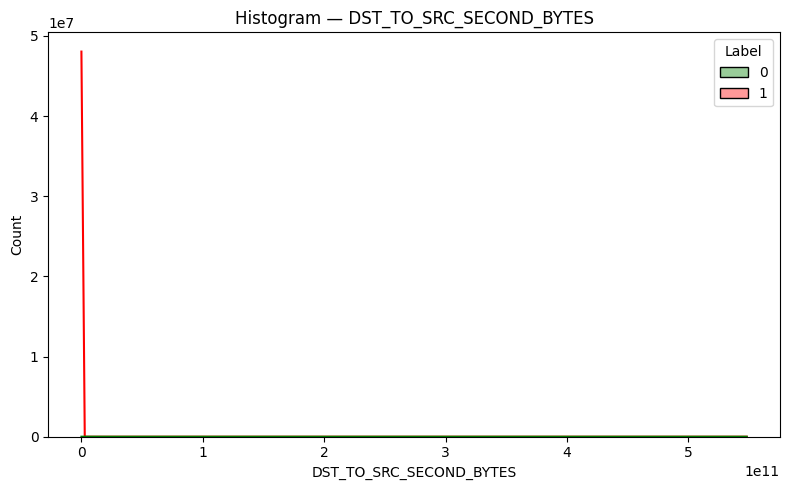

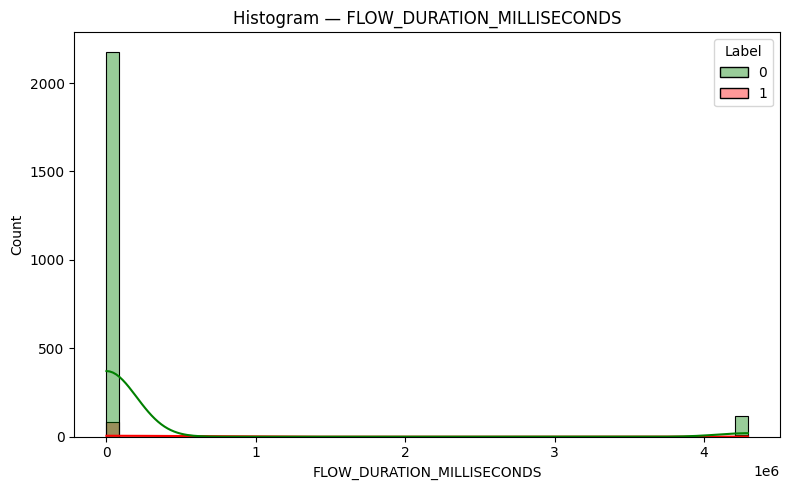

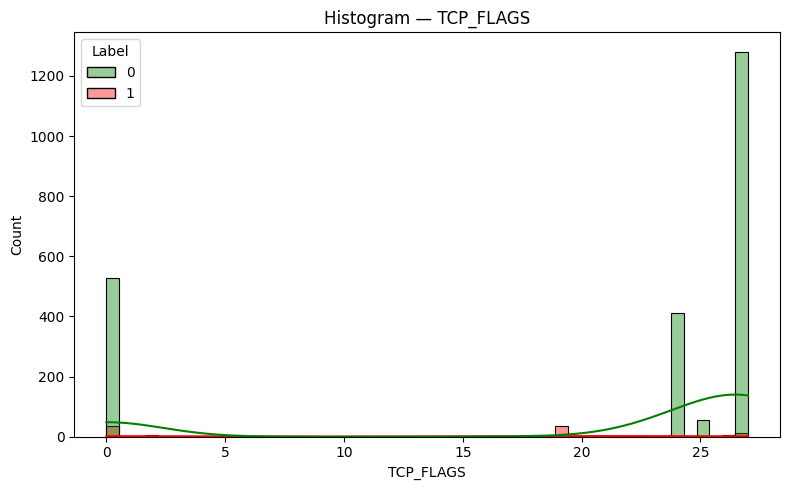

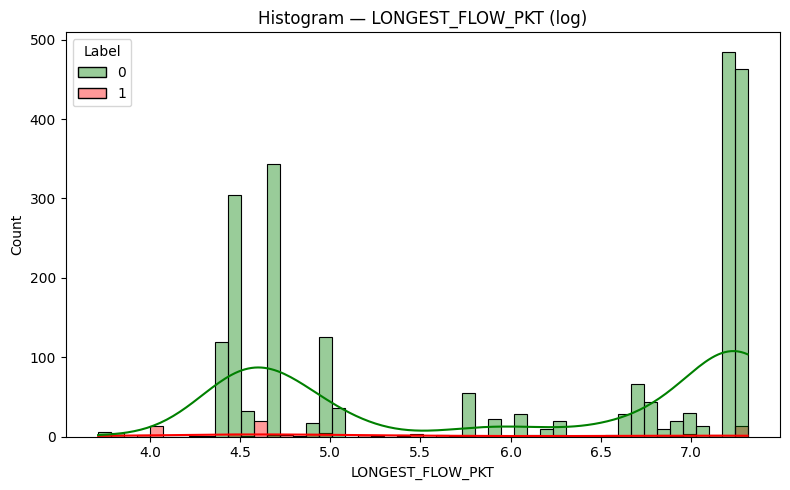

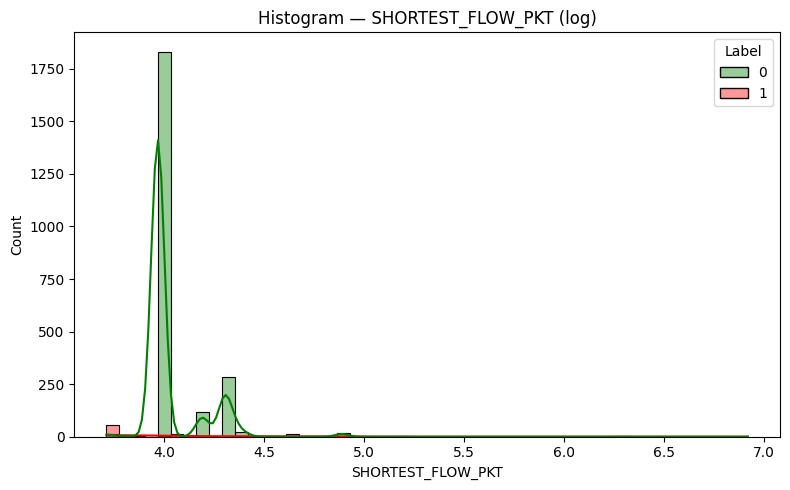

In [14]:
import seaborn as sns

for col in top_features:

    if col not in numeric_df.columns:
        continue

    plt.figure(figsize=(8,5))

    values = numeric_df[col]

    if (values > 0).all():
        values_plot = np.log1p(values)
        title = f"{col} (log)"
    else:
        values_plot = values
        title = col

    sns.histplot(
        x=values_plot,
        hue=df_sample["Label"],
        bins=50,
        kde=True,
        palette=["green", "red"],
        alpha=0.4
    )

    plt.title(f"Histogram — {title}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()


In [15]:
top_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "FLOW_DURATION_MILLISECONDS",
    "TCP_FLAGS",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT"
]
